# Half-Cauchy Distribution

`HalfCauchy(scale)` is a continuous distribution on `[0, infinity)`: the distribution of `|X|` where `X` is a `Cauchy(0, scale)`. Like the `HalfNormal` it peaks at 0, but its tail is far heavier -- it keeps real probability a long way from 0. That is exactly why it is the usual recommendation as a prior for a group-level standard deviation in a hierarchical Bayesian model: it stays open to large values instead of quietly ruling them out.

In [1]:
from symbulate import *

## Draw a value from a Half-Cauchy distribution

In [2]:
HalfCauchy(scale=2).draw()

2.0741205087887225

## The mean, variance, and standard deviation are infinite

The Half-Cauchy inherits the Cauchy's heavy tail, and that tail is heavy enough that the integrals defining these quantities do not converge. Symbulate reports each of them as `inf` rather than a finite number.

In [3]:
HalfCauchy(scale=2).mean(), HalfCauchy(scale=2).var(), HalfCauchy(scale=2).sd()

(np.float64(inf), np.float64(inf), np.float64(inf))

So use the **median** to describe the center instead. For a Half-Cauchy the median is exactly `scale`.

In [4]:
HalfCauchy(scale=2).median()

np.float64(1.9999999999999998)

## Assign and simulate a random variable

In [5]:
H = RV(HalfCauchy(scale=2))
H.sim(10000)

0,6.613831035605556
1,0.17512473913503404
2,0.8575012927794023
3,0.4226369041478881
4,3.2084288535100933
5,0.0042706955438209645
6,1.149197282039394
7,44.62025590607586
8,0.6741347960263893
...,...
9999,6.346187789396436


## Plot the pdf

The default plotting window is chosen to hold almost all of the probability. For a Half-Cauchy that means reaching a very long way out along the tail, so the density looks like a spike against a wide axis. This is an honest picture of how spread out the distribution is, but it does not show the shape.

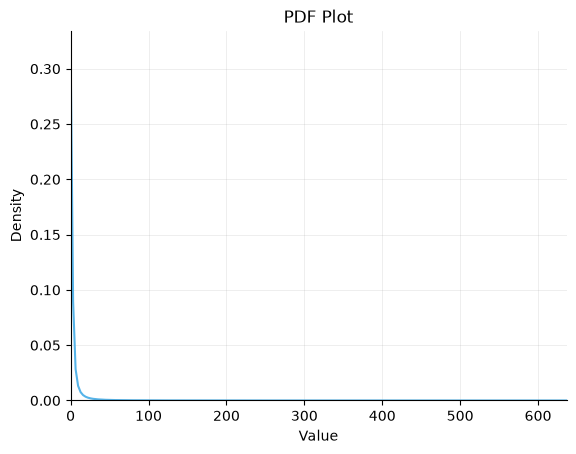

In [6]:
HalfCauchy(scale=2).plot()

Set a window on the distribution to look at the bulk of it. (`plot()` takes no window argument: it frames itself, and a tail this heavy gives it nothing to trim.) The density is highest at 0 (at a height of `2 / (pi * scale)`) and decreases from there.

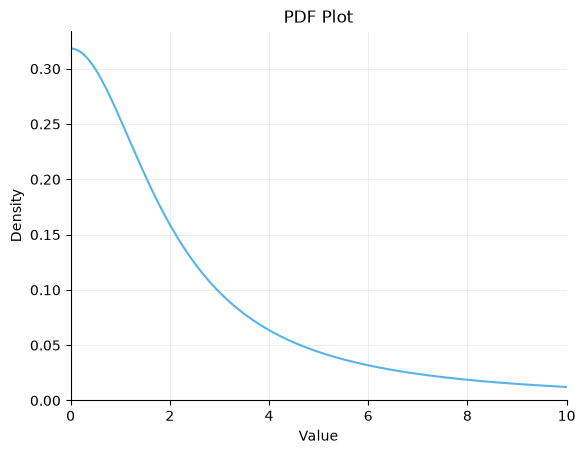

In [7]:
C = HalfCauchy(scale=2)
C.xlim = (0, 10)
C.plot()

## Plot the CDF

The CDF climbs steeply at first and then flattens out without ever quite reaching 1 on this window -- the missing probability is out in the tail.

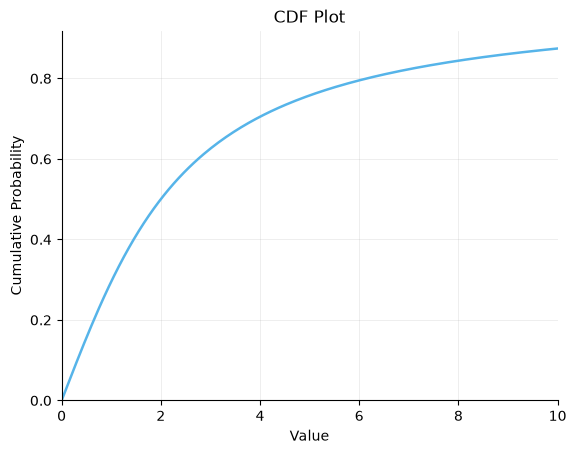

In [8]:
C.plot(cdf=True)

## Scale parameter changes the spread

A smaller scale concentrates the distribution near 0; a larger one spreads it out. The scale is also the median, so it marks the point where half the probability lies on either side.

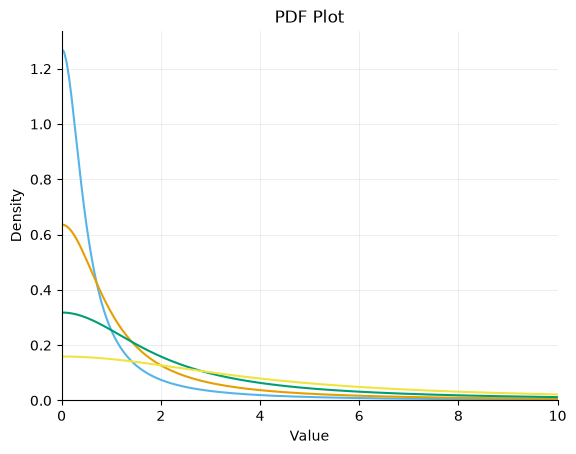

In [9]:
for s in [0.5, 1, 2, 4]:
    D = HalfCauchy(scale=s)
    D.xlim = (0, 10)
    D.plot()

## The heavy tail makes a histogram of simulated values unhelpful

A handful of simulated values land enormously far from 0, so an automatically-binned histogram has to span that whole range -- and then nearly every value falls into the first bin. Notice the scale on the horizontal axis.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


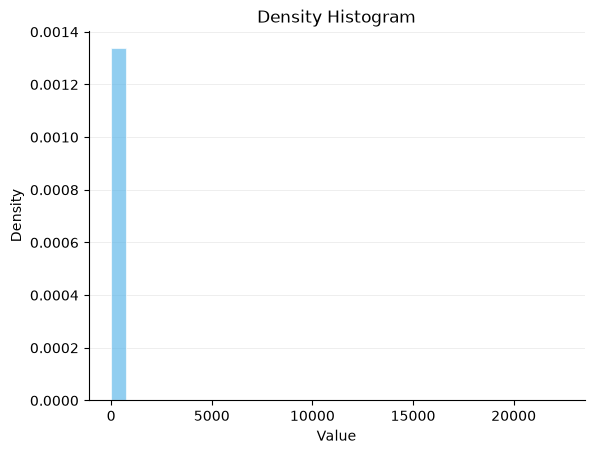

In [10]:
H.sim(10000).plot()

## Relationship: the absolute value of a Cauchy

This is the definition of the distribution: `|X|` for `X` a `Cauchy(0, 2)` is a `HalfCauchy(2)`. Because of the tail problem above, the comparison is much clearer using the CDF than the pdf -- a cumulative curve is unaffected by a few extreme values. Here the simulated ECDF sits right on top of the theoretical CDF.

Two small things about the code below. The theoretical curve is drawn *first*, on the `C.xlim = (0, 10)` window set a few cells up, so that it is computed on a fine grid across the window we actually want to see. Then `xlim(0, 10)` at the end trims the axis back down, because plotting the simulated values stretches it out to cover their full range; the `;` on that line just hides the pair of limits `xlim` hands back.

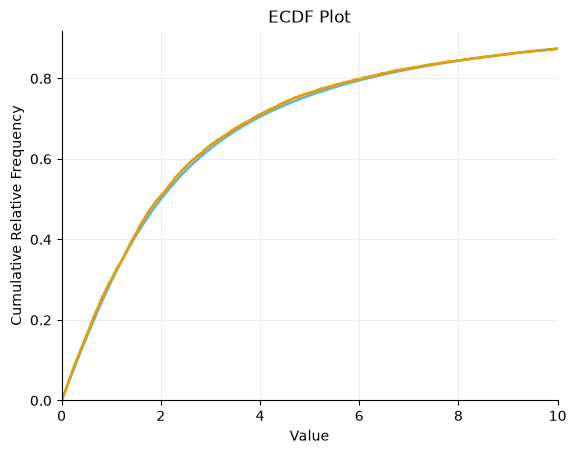

In [11]:
C.plot(cdf=True)
X = RV(Cauchy(loc=0, scale=2))
X.apply(abs).sim(10000).plot(type="ecdf")
xlim(0, 10);

## Comparison: Half-Cauchy and Half-Normal

Both fold a symmetric distribution at 0 and both peak there, but they behave very differently further out. The Half-Normal starts higher (`0.798` versus `0.637` at scale 1) and then dies off quickly -- by 4 it is essentially gone. The Half-Cauchy starts lower and keeps a visible amount of density all the way across. That persistent tail is what makes it the more permissive choice of prior.

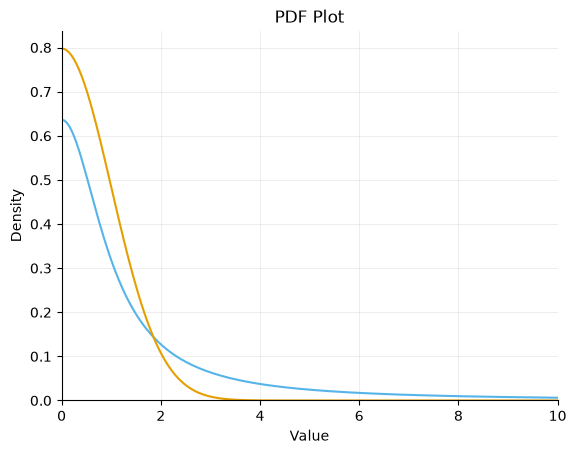

In [12]:
for D in [HalfCauchy(scale=1), HalfNormal(scale=1)]:
    D.xlim = (0, 10)
    D.plot()

The difference is easier to quantify than to see. The probability of landing past 10 is tiny for the Half-Normal but very much real for the Half-Cauchy.

In [13]:
1 - HalfCauchy(scale=1).cdf(10), 1 - HalfNormal(scale=1).cdf(10)

(np.float64(0.06345103486110704), np.float64(0.0))